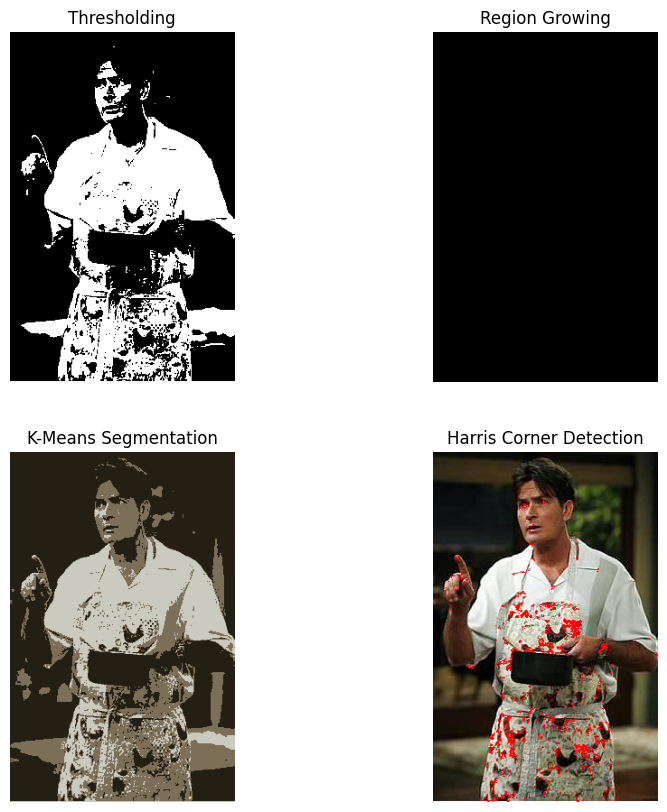

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label
from sklearn.cluster import KMeans

def thresholding(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return thresh

def region_growing(image, seed=(50, 50)):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    mask = np.zeros_like(gray, dtype=np.uint8)
    mask[seed] = 255
    while True:
        new_mask = cv2.dilate(mask, None) & (gray > 100)
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return mask

def kmeans_segmentation(image, k=3):
    pixel_values = image.reshape((-1, 3))
    pixel_values = np.float32(pixel_values)
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(pixel_values)
    segmented_image = kmeans.cluster_centers_[labels].reshape(image.shape)
    return np.uint8(segmented_image)

def harris_corner_detection(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray = np.float32(gray)
    dst = cv2.cornerHarris(gray, 2, 3, 0.04)
    image[dst > 0.01 * dst.max()] = [0, 0, 255]
    return image

def main(image_path):
    image = cv2.imread(image_path)
    if image is None:
        print("Error loading image!")
        return
    
    thresh = thresholding(image)
    region = region_growing(image)
    kmeans = kmeans_segmentation(image)
    harris = harris_corner_detection(image.copy())
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes[0, 0].imshow(thresh, cmap='gray')
    axes[0, 0].set_title('Thresholding')
    axes[0, 1].imshow(region, cmap='gray')
    axes[0, 1].set_title('Region Growing')
    axes[1, 0].imshow(cv2.cvtColor(kmeans, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title('K-Means Segmentation')
    axes[1, 1].imshow(cv2.cvtColor(harris, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title('Harris Corner Detection')
    
    for ax in axes.flat:
        ax.axis('off')
    plt.show()

if __name__ == "__main__":
    main(r"C:\Users\johnt\Documents\VS Code\Codes\Sem 2\Deep Learning\Lab 2\Img.jpeg")  # Change to the path of your image
